✅ Loaded file from: /content/8000.3.xlsx

📋 Columns in dataset:
['ExtracurricularActivities', 'ZHoursStudied', 'ZPreviousScores', 'ZSleepHours', 'ZSampleQuestionPapersPracticed', 'ZPerformanceIndex']

📊 Data types:
ExtracurricularActivities          object
ZHoursStudied                     float64
ZPreviousScores                   float64
ZSleepHours                       float64
ZSampleQuestionPapersPracticed    float64
ZPerformanceIndex                 float64
dtype: object

🎯 Dependent Variable: ZPerformanceIndex

✅ 'ExtracurricularActivities' dummy variable set with 'No' as baseline:


,count
ExtracurricularActivities,
0,4085
1,3915



📄 Regression formula:
ZPerformanceIndex ~ C(ExtracurricularActivities, Treatment(reference=0)) + ZHoursStudied + ZPreviousScores + ZSleepHours + ZSampleQuestionPapersPracticed

📊 OLS Regression Summary:


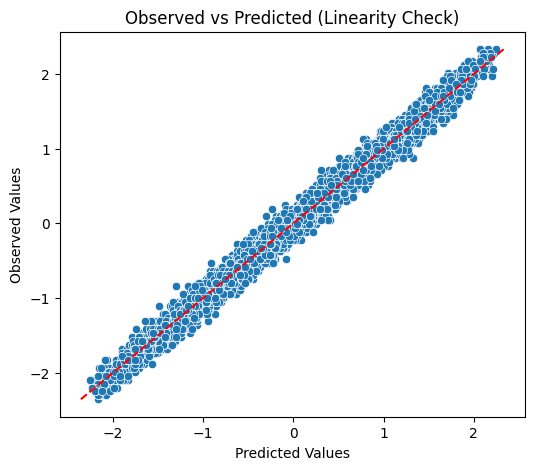

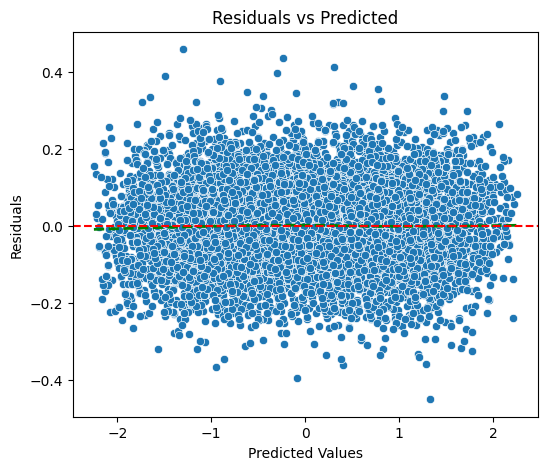

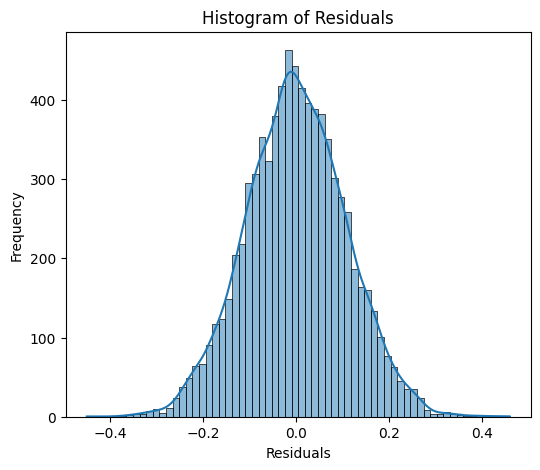

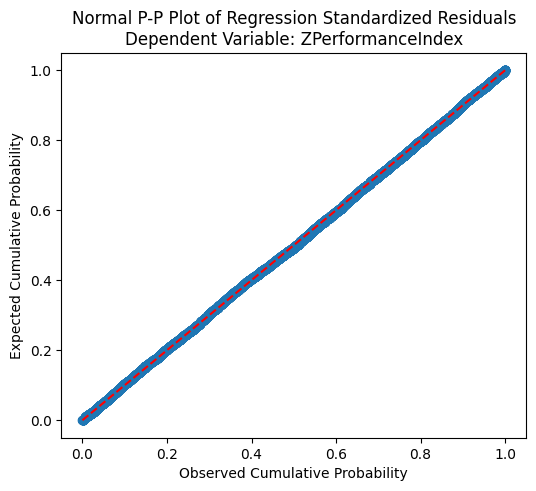


🧪 Shapiro-Wilk Test:
Statistic=0.9997, p-value=0.2596
✅ Residuals appear normally distributed

🧪 Heteroscedasticity Tests:
Breusch-Pagan LM stat=0.6310, p-value=0.9865
White Test LM stat=15.3006, p-value=0.7033
✅ No heteroscedasticity


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8000.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# 🔹 Multiple Regression (SPSS-Compatible + Full Diagnostic Version)
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.api import het_breuschpagan, het_white
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML
import numpy as np

# === 1. ระบุ path ของไฟล์ Excel ===
path = "/content/8000.3.xlsx"

# === 2. โหลดข้อมูล ===
data = pd.read_excel(path)
print(f"✅ Loaded file from: {path}")

# === 3. ตรวจสอบคอลัมน์ ===
print("\n📋 Columns in dataset:")
print(data.columns.tolist())
print("\n📊 Data types:")
print(data.dtypes)

# === 4. ระบุตัวแปรตาม ===
target_column = data.columns[-1]
print(f"\n🎯 Dependent Variable: {target_column}")

# === 5. แปลง Yes/No เป็น dummy (No = baseline) ===
for col in data.columns:
    if data[col].dtype == 'object':
        if set(data[col].dropna().unique()) <= {'Yes', 'No'}:
            data[col] = data[col].map({'No': 0, 'Yes': 1})

# ยืนยัน ExtracurricularActivities
if 'ExtracurricularActivities' in data.columns:
    print("\n✅ 'ExtracurricularActivities' dummy variable set with 'No' as baseline:")
    display(data['ExtracurricularActivities'].value_counts())

# === 6. Standardize ตัวแปร numeric (ไม่รวมตัวแปร categorical และ dependent) ===
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_column]
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# ==========================================================
# 🟩 STEP 0: สร้าง formula แบบ explicit dummy baseline
# ==========================================================
predictors = []
for col in data.columns:
    if col == target_column:
        continue
    if col == 'ExtracurricularActivities':
        predictors.append(f"C({col}, Treatment(reference=0))")  # 0 = No
    else:
        predictors.append(col)

formula = f"{target_column} ~ " + " + ".join(predictors)
print("\n📄 Regression formula:")
print(formula)

# ==========================================================
# 🟩 STEP 1: OLS Regression
# ==========================================================
model = smf.ols(formula=formula, data=data).fit()
print("\n📊 OLS Regression Summary:")
display(HTML(model.summary().as_html()))

# ==========================================================
# 🟩 STEP 2: Observed vs Predicted
# ==========================================================
predicted = model.fittedvalues
y = data[target_column]

plt.figure(figsize=(6,5))
sns.scatterplot(x=predicted, y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title("Observed vs Predicted (Linearity Check)")
plt.xlabel("Predicted Values")
plt.ylabel("Observed Values")
plt.show()

# ==========================================================
# 🟩 STEP 3: Residuals vs Predicted (Homoscedasticity)
# ==========================================================
residuals = model.resid
plt.figure(figsize=(6,5))
sns.scatterplot(x=predicted, y=residuals)
sns.regplot(x=predicted, y=residuals, lowess=True, scatter=False, color='green', line_kws={'linestyle': '--','linewidth':2})
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# ==========================================================
# 🟩 STEP 4: Normality Check (Histogram + P-P Plot)
# ==========================================================
# Histogram of Residuals
plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Standardized residuals
standardized_resid = (residuals - np.mean(residuals)) / np.std(residuals)

# Normal P-P Plot (Observed Cum Prob on X, Expected Cum Prob on Y)
observed_sorted = np.sort(standardized_resid)
observed_cdf = np.arange(1, len(observed_sorted)+1) / (len(observed_sorted)+1)
from scipy.stats import norm
expected_cdf = norm.cdf(observed_sorted)

plt.figure(figsize=(6,5))
plt.scatter(observed_cdf, expected_cdf)
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("Observed Cumulative Probability")
plt.ylabel("Expected Cumulative Probability")
plt.title(f"Normal P-P Plot of Regression Standardized Residuals\nDependent Variable: {target_column}")
plt.show()

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)
print("\n🧪 Shapiro-Wilk Test:")
print(f"Statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("✅ Residuals appear normally distributed")
else:
    print("⚠️ Residuals deviate from normality")

# ==========================================================
# 🟩 STEP 5: Heteroscedasticity Tests
# ==========================================================
print("\n🧪 Heteroscedasticity Tests:")
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan LM stat={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

white_test = het_white(residuals, model.model.exog)
print(f"White Test LM stat={white_test[0]:.4f}, p-value={white_test[1]:.4f}")

if bp_test[1] < 0.05 or white_test[1] < 0.05:
    print("⚠️ Heteroscedasticity detected")
else:
    print("✅ No heteroscedasticity")


✅ Loaded file from: /content/8000.3.xlsx

📋 Columns in dataset:
['ExtracurricularActivities', 'ZHoursStudied', 'ZPreviousScores', 'ZSleepHours', 'ZSampleQuestionPapersPracticed', 'ZPerformanceIndex']

📊 Data types:
ExtracurricularActivities          object
ZHoursStudied                     float64
ZPreviousScores                   float64
ZSleepHours                       float64
ZSampleQuestionPapersPracticed    float64
ZPerformanceIndex                 float64
dtype: object

🎯 Dependent Variable: ZPerformanceIndex

✅ 'ExtracurricularActivities' dummy variable set with 'No' as baseline:


,count
ExtracurricularActivities,
0,4085
1,3915



🔹 Pearson Correlation Matrix:


,ExtracurricularActivities,ZHoursStudied,ZPreviousScores,ZSleepHours,ZSampleQuestionPapersPracticed,ZPerformanceIndex
ExtracurricularActivities,1.000,0.002,0.009,-0.018,0.009,0.024
ZHoursStudied,0.002,1.000,-0.018,0.008,0.023,0.369
ZPreviousScores,0.009,-0.018,1.000,0.005,0.013,0.915
ZSleepHours,-0.018,0.008,0.005,1.000,0.010,0.049
ZSampleQuestionPapersPracticed,0.009,0.023,0.013,0.010,1.000,0.050
ZPerformanceIndex,0.024,0.369,0.915,0.049,0.050,1.000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


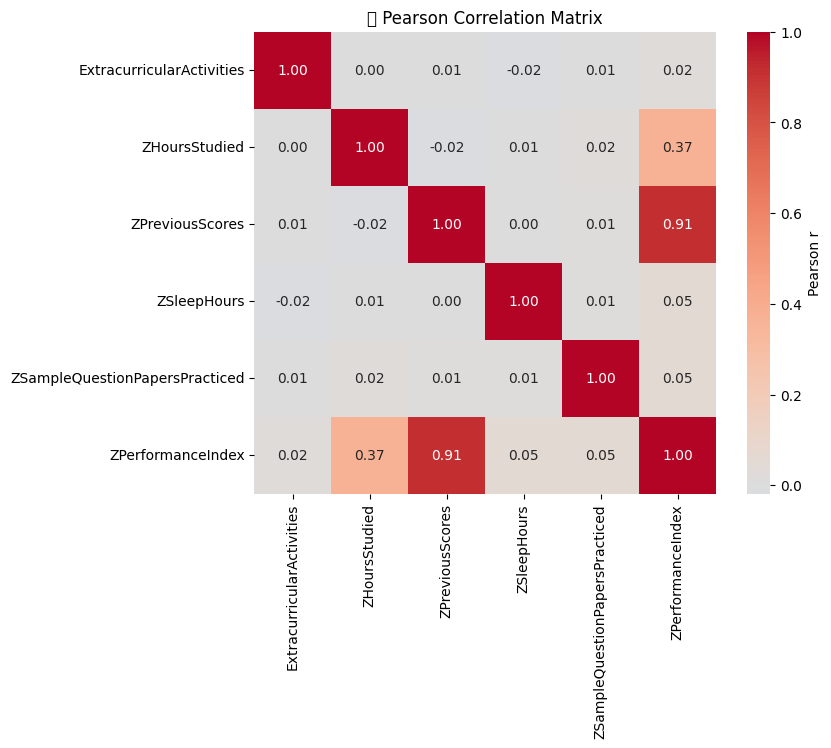


📈 Correlation with Dependent Variable:


,ZPerformanceIndex
ZPerformanceIndex,1.000
ZPreviousScores,0.915
ZHoursStudied,0.369
ZSampleQuestionPapersPracticed,0.050
ZSleepHours,0.049
ExtracurricularActivities,0.024



🧮 Variance Inflation Factor (VIF):


,Variable,VIF
0,ExtracurricularActivities,1.000
1,ZHoursStudied,1.001
2,ZPreviousScores,1.001
3,ZSleepHours,1.000
4,ZSampleQuestionPapersPracticed,1.001
5,const,1.000



📄 Regression formula:
ZPerformanceIndex ~ C(ExtracurricularActivities, Treatment(reference=0)) + ZHoursStudied + ZPreviousScores + ZSleepHours + ZSampleQuestionPapersPracticed

📊 OLS Regression Summary:


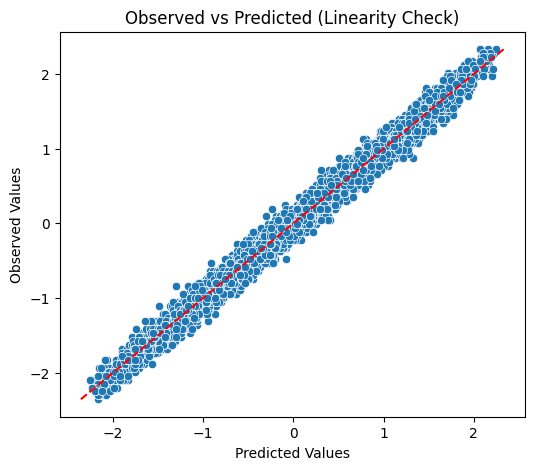

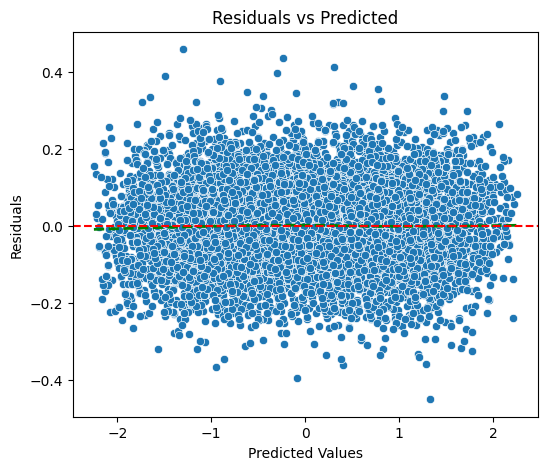

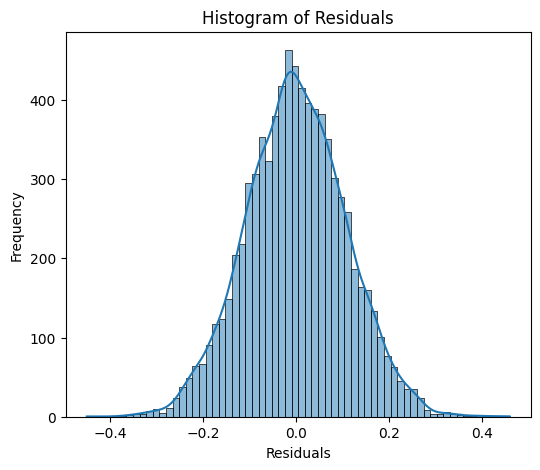

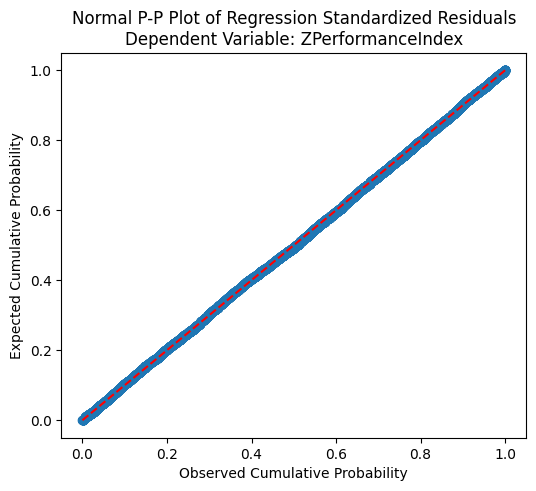


🧪 Shapiro-Wilk Test:
Statistic=0.9997, p-value=0.2596
✅ Residuals appear normally distributed

🧪 Heteroscedasticity Tests:
Breusch-Pagan LM stat=0.6310, p-value=0.9865
White Test LM stat=15.3006, p-value=0.7033
✅ No heteroscedasticity


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8000.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# ==========================================================
# 🔹 Multiple Regression (SPSS-Compatible + Full Diagnostics + Pearson Corr + VIF)
# ==========================================================

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.api import het_breuschpagan, het_white
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, HTML
import numpy as np

# === 1. ระบุ path ของไฟล์ Excel ===
path = "/content/8000.3.xlsx"

# === 2. โหลดข้อมูล ===
data = pd.read_excel(path)
print(f"✅ Loaded file from: {path}")

# === 3. ตรวจสอบคอลัมน์ ===
print("\n📋 Columns in dataset:")
print(data.columns.tolist())
print("\n📊 Data types:")
print(data.dtypes)

# === 4. ระบุตัวแปรตาม ===
target_column = data.columns[-1]
print(f"\n🎯 Dependent Variable: {target_column}")

# === 5. แปลง Yes/No เป็น dummy (No = baseline) ===
for col in data.columns:
    if data[col].dtype == 'object':
        if set(data[col].dropna().unique()) <= {'Yes', 'No'}:
            data[col] = data[col].map({'No': 0, 'Yes': 1})

# ยืนยัน ExtracurricularActivities
if 'ExtracurricularActivities' in data.columns:
    print("\n✅ 'ExtracurricularActivities' dummy variable set with 'No' as baseline:")
    display(data['ExtracurricularActivities'].value_counts())

# === 6. Standardize ตัวแปร numeric (ไม่รวมตัวแปร categorical และ dependent) ===
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_column]
scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# ==========================================================
# 🟩 STEP 0.5: Pearson Correlation Matrix (Pairwise)
# ==========================================================
print("\n🔹 Pearson Correlation Matrix:")
corr = data[numeric_cols + [target_column]].corr(method='pearson')
display(corr.round(3))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True,
            cbar_kws={'label': 'Pearson r'})
plt.title("🔹 Pearson Correlation Matrix")
plt.show()

target_corr = corr[target_column].sort_values(ascending=False)
print("\n📈 Correlation with Dependent Variable:")
display(target_corr.round(3))

# ==========================================================
# 🟩 STEP 0.6: ตรวจสอบ Multicollinearity (VIF)
# ==========================================================
print("\n🧮 Variance Inflation Factor (VIF):")

# เตรียม X สำหรับคำนวณ VIF (ไม่รวม dependent variable)
X_vif = data[numeric_cols].assign(const=1)
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_data.round(3))

# ==========================================================
# 🟩 STEP 1: Regression Formula
# ==========================================================
predictors = []
for col in data.columns:
    if col == target_column:
        continue
    if col == 'ExtracurricularActivities':
        predictors.append(f"C({col}, Treatment(reference=0))")  # 0 = No
    else:
        predictors.append(col)

formula = f"{target_column} ~ " + " + ".join(predictors)
print("\n📄 Regression formula:")
print(formula)

# ==========================================================
# 🟩 STEP 2: OLS Regression
# ==========================================================
model = smf.ols(formula=formula, data=data).fit()
print("\n📊 OLS Regression Summary:")
display(HTML(model.summary().as_html()))

# ==========================================================
# 🟩 STEP 3: Observed vs Predicted
# ==========================================================
predicted = model.fittedvalues
y = data[target_column]

plt.figure(figsize=(6,5))
sns.scatterplot(x=predicted, y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title("Observed vs Predicted (Linearity Check)")
plt.xlabel("Predicted Values")
plt.ylabel("Observed Values")
plt.show()

# ==========================================================
# 🟩 STEP 4: Residuals vs Predicted (Homoscedasticity)
# ==========================================================
residuals = model.resid
plt.figure(figsize=(6,5))
sns.scatterplot(x=predicted, y=residuals)
sns.regplot(x=predicted, y=residuals, lowess=True, scatter=False, color='green', line_kws={'linestyle': '--','linewidth':2})
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# ==========================================================
# 🟩 STEP 5: Normality Check (Histogram + P-P Plot)
# ==========================================================
plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

standardized_resid = (residuals - np.mean(residuals)) / np.std(residuals)
observed_sorted = np.sort(standardized_resid)
observed_cdf = np.arange(1, len(observed_sorted)+1) / (len(observed_sorted)+1)
from scipy.stats import norm
expected_cdf = norm.cdf(observed_sorted)

plt.figure(figsize=(6,5))
plt.scatter(observed_cdf, expected_cdf)
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("Observed Cumulative Probability")
plt.ylabel("Expected Cumulative Probability")
plt.title(f"Normal P-P Plot of Regression Standardized Residuals\nDependent Variable: {target_column}")
plt.show()

shapiro_test = stats.shapiro(residuals)
print("\n🧪 Shapiro-Wilk Test:")
print(f"Statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("✅ Residuals appear normally distributed")
else:
    print("⚠️ Residuals deviate from normality")

# ==========================================================
# 🟩 STEP 6: Heteroscedasticity Tests
# ==========================================================
print("\n🧪 Heteroscedasticity Tests:")
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan LM stat={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")

white_test = het_white(residuals, model.model.exog)
print(f"White Test LM stat={white_test[0]:.4f}, p-value={white_test[1]:.4f}")

if bp_test[1] < 0.05 or white_test[1] < 0.05:
    print("⚠️ Heteroscedasticity detected")
else:
    print("✅ No heteroscedasticity")
